<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/weighted_Categorical_CE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


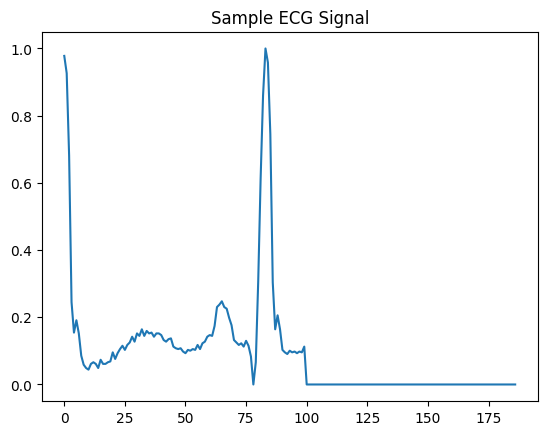

In [23]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

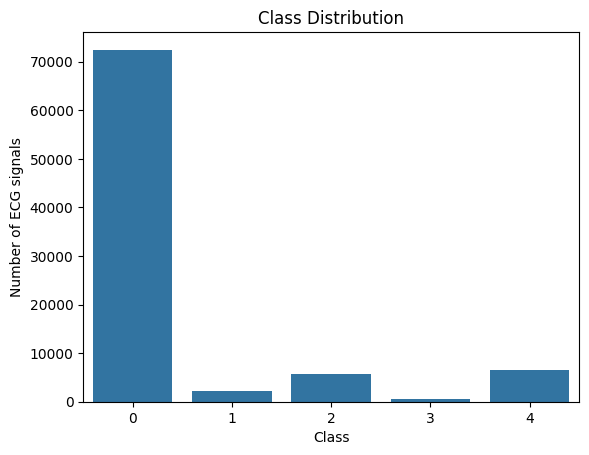

In [24]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)
plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

In [25]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [26]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]



In [27]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [28]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [30]:
classes_unique = np.unique(y_res)
class_weights = compute_class_weight(class_weight='balanced', classes=classes_unique, y=y_res)
class_weights_dict = dict(zip(classes_unique, class_weights))

print("Class weights:", class_weights_dict)

Class weights: {np.float64(0.0): np.float64(1.0), np.float64(1.0): np.float64(1.0), np.float64(2.0): np.float64(1.0), np.float64(3.0): np.float64(1.0), np.float64(4.0): np.float64(1.0)}


In [31]:
def weighted_categorical_crossentropy(weights):
    weights = tf.constant(weights, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        weight_vector = tf.reduce_sum(weights * y_true, axis=-1)
        return ce * weight_vector

    return loss_fn

In [32]:
def mobilenet_ecg():
    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    # Compile with weighted categorical crossentropy
    model.compile(
        optimizer='adam',
        loss=weighted_categorical_crossentropy(list(class_weights_dict.values())),
        metrics=['accuracy']
    )

    return model

model = mobilenet_ecg()

In [33]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 379s 80ms/step - accuracy: 0.9094 - loss: 0.2582 - val_accuracy: 0.9470 - val_loss: 0.1568
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 297s 66ms/step - accuracy: 0.9773 - loss: 0.0665 - val_accuracy: 0.9673 - val_loss: 0.0934
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 306s 68ms/step - accuracy: 0.9850 - loss: 0.0448 - val_accuracy: 0.9830 - val_loss: 0.0480
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 319s 70ms/step - accuracy: 0.9881 - loss: 0.0343 - val_accuracy: 0.9700 - val_loss: 0.0867
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 305s 67ms/step - accuracy: 0.9905 - loss: 0.0283 - val_accuracy: 0.9768 - val_loss: 0.0675
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 306s 68ms/step - accuracy: 0.9918 - loss: 0.0238 - val_accuracy: 0.9913 - val_loss: 0.0262
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 312s 69ms/step - accuracy: 0.9932 - loss: 0.0196 - val_accuracy: 0.9874 - val_loss: 0.0361
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 304s 67ms/step - accuracy: 

In [34]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step
Validation MCC: 0.9912259045828254


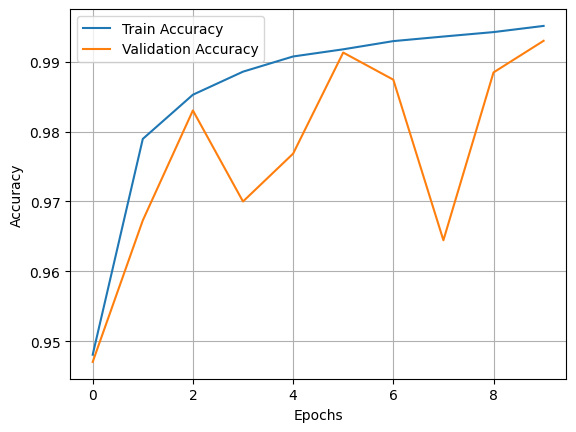

In [35]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

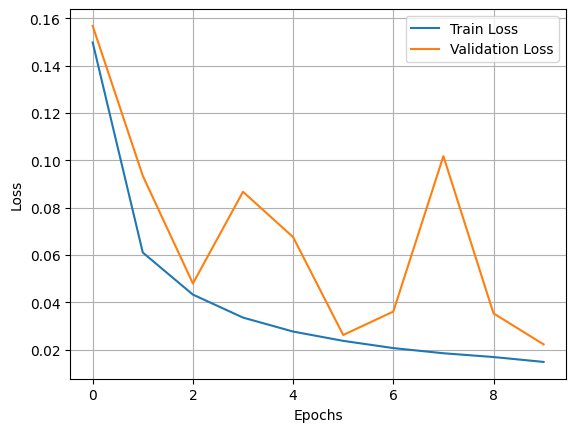

In [36]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [37]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.68      0.81      0.74       556
         2.0       0.98      0.94      0.96      1448
         3.0       0.81      0.78      0.80       162
         4.0       0.98      0.99      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.89      0.90      0.89     21892
weighted avg       0.98      0.98      0.98     21892



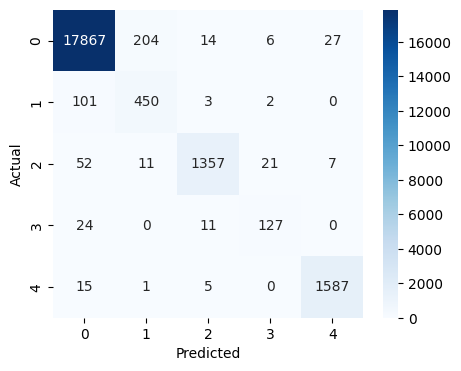

In [38]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

X_res = np.array(X_res).reshape(-1,187,1)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=0
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)
    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
